# Tutorial 15-1: The Grid World Navigator – "Q-Learning from Scratch"

**Course:** CSEN 342: Deep Learning  
**Topic:** Reinforcement Learning, Markov Decision Processes (MDP), and Tabular Q-Learning

## Objective
Before we can understand *Deep* Reinforcement Learning, we must understand the fundamental math behind it. 

The core idea of RL is the **Q-Function** $Q(s, a)$, which tells us: *"If I am in state $s$ and take action $a$, how much total reward can I expect to get in the future?"* (Slide 27).

If we know the perfect Q-Function, the optimal policy is simple: just pick the action with the highest Q-value.

In this tutorial, we will:
1.  **Build a Grid World:** A simple environment with a Goal (+1), a Pit (-1), and Walls (Slide 20).
2.  **Create a Q-Table:** A simple lookup table to store Q-values.
3.  **Implement Q-Learning:** Use the Bellman Equation to update the table from experience.
4.  **Visualize the Policy:** See the optimal path emerge.

---

## Part 1: The Grid World Environment

We define a simple $3 \times 4$ world.
* **States:** Coordinates $(row, col)$.
* **Actions:** 0=Up, 1=Right, 2=Down, 3=Left.
* **Rewards:** +1 at (0, 3), -1 at (1, 3), -0.01 per step (to encourage speed).
* **Walls:** Block at (1, 1).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

class GridWorld:
    def __init__(self):
        self.height = 3
        self.width = 4
        self.grid = np.zeros((self.height, self.width)) - 1
        
        # Define special states
        self.goal = (0, 3)
        self.pit = (1, 3)
        self.wall = (1, 1)
        self.start = (2, 0)
        
        # Current state
        self.agent_pos = self.start

    def reset(self):
        self.agent_pos = self.start
        return self.agent_pos

    def step(self, action):
        # Actions: 0=Up, 1=Right, 2=Down, 3=Left
        # Directions corresponding to actions
        dirs = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        move = dirs[action]
        
        # Calculate new position
        new_pos = (self.agent_pos[0] + move[0], self.agent_pos[1] + move[1])
        
        # Check bounds
        if new_pos[0] < 0 or new_pos[0] >= self.height or \
           new_pos[1] < 0 or new_pos[1] >= self.width:
            new_pos = self.agent_pos # Hit edge, stay put
            
        # Check Wall
        if new_pos == self.wall:
            new_pos = self.agent_pos # Hit wall, stay put
            
        self.agent_pos = new_pos
        
        # Check Rewards and Termination
        done = False
        reward = -0.01 # Small penalty for each step to encourage shortest path
        
        if self.agent_pos == self.goal:
            reward = 1
            done = True
        elif self.agent_pos == self.pit:
            reward = -1
            done = True
            
        return self.agent_pos, reward, done

env = GridWorld()
print("Grid World Initialized.")

Grid World Initialized.


---

## Part 2: The Q-Table Agent

In deep learning, we approximate $Q(s,a)$ with a neural net. Here, since we only have 12 states and 4 actions, we can just use a table of size $3 \times 4 \times 4$.

We need an **Epsilon-Greedy** policy:
* With probability $\epsilon$, pick a random action (Explore).
* Otherwise, pick the action with the highest Q-value (Exploit).

In [2]:
# Q-Table: Height x Width x Actions
q_table = np.zeros((3, 4, 4))

def choose_action(state, epsilon=0.1):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, 3) # Explore
    else:
        # Exploit: return index of max Q value
        return np.argmax(q_table[state[0], state[1]])

---

## Part 3: The Q-Learning Algorithm

This is the heart of the tutorial. We update the Q-Table using the **Bellman Equation** (Slide 31).

$$ Q_{new}(s,a) = Q_{old}(s,a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q_{old}(s,a)] $$

Where:
* $\alpha$: Learning Rate
* $\gamma$: Discount Factor (how much we care about future rewards)
* $r$: Immediate reward
* $\max Q(s', a')$: The best we can do from the *next* state.

In [3]:
# Hyperparameters
alpha = 0.5   # Learning Rate
gamma = 0.9   # Discount Factor
epsilon = 0.05 # Exploration Rate
episodes = 500

print("Starting Training...")

for episode in range(episodes):
    state = env.reset()
    done = False
    
    while not done:
        # 1. Choose Action
        action = choose_action(state, epsilon)
        
        # 2. Act
        next_state, reward, done = env.step(action)
        
        # 3. Get Old Q-value
        old_value = q_table[state[0], state[1], action]
        
        # 4. Get Max Q-value for Next State
        # If terminal, there is no future, so max_next is 0
        if done:
            next_max = 0
        else:
            next_max = np.max(q_table[next_state[0], next_state[1]])
        
        # 5. Update Q-Table (Bellman Equation)
        # New Value = Old + Alpha * (Target - Old)
        new_value = old_value + alpha * (reward + gamma * next_max - old_value)
        q_table[state[0], state[1], action] = new_value
        
        state = next_state

print("Training Complete.")

Starting Training...
Training Complete.


---

## Part 4: Visualization (The Policy)

We have a table of numbers. Let's translate that into a map. 
For each cell, we will draw an arrow pointing in the direction of the action with the highest Q-value.

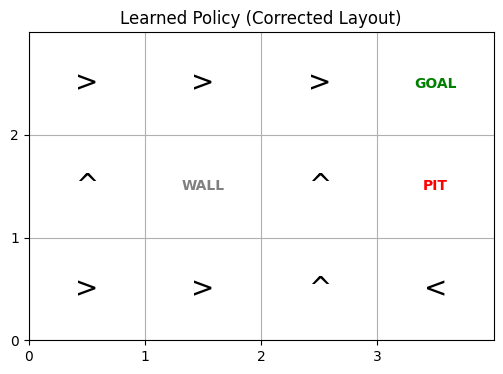

In [4]:
def plot_policy(q_table):
    h, w, _ = q_table.shape
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Draw Grid
    ax.set_xlim(0, w)
    ax.set_ylim(0, h)
    ax.set_xticks(np.arange(w))
    ax.set_yticks(np.arange(h))
    ax.grid(True)
    
    # Label Special States (Row 0 is at y=2.5, Row 1 at y=1.5, Row 2 at y=0.5)
    ax.text(3.5, 2.5, 'GOAL', ha='center', va='center', color='green', fontweight='bold')
    ax.text(3.5, 1.5, 'PIT', ha='center', va='center', color='red', fontweight='bold')
    ax.text(1.5, 1.5, 'WALL', ha='center', va='center', color='gray', fontweight='bold')
    
    # Draw Arrows
    actions = ['^', '>', 'v', '<'] # 0=Up, 1=Right, 2=Down, 3=Left
    
    for r in range(h):
        for c in range(w):
            if (r, c) == (0, 3) or (r, c) == (1, 3) or (r, c) == (1, 1):
                continue 
            
            best_action = np.argmax(q_table[r, c])
            
            # Map matrix row 'r' to plot 'y'
            # r=0 (top) -> y=2.5
            # r=2 (bottom) -> y=0.5
            plot_y = h - r - 0.5
            plot_x = c + 0.5
            
            ax.text(plot_x, plot_y, actions[best_action], ha='center', va='center', fontsize=20)
            
    plt.title("Learned Policy (Corrected Layout)")
    # REMOVED: plt.gca().invert_yaxis() 
    plt.show()

plot_policy(q_table)

### Conclusion

Look at the arrows. You should see the agent learned to:
1.  Avoid the Pit (it goes around it).
2.  Navigate around the Wall.
3.  Head towards the Goal from any starting point.

This works for small grids. But what if the grid had 1 million squares? The table would be too big. That's where **Deep Q-Learning** (using a Neural Network instead of a table) comes in, which we will explore in the next tutorial.